Mounted at /content/drive
Training BiGRU NU = 15 Dense = S2
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step
Training BiGRU NU = 15 Dense = R2
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step
Training BiGRU NU = 30 Dense = S2
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step
Training BiGRU NU = 30 Dense = R2
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step
Training BiGRU NU = 40 Dense = S2
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step
Training BiGRU NU = 40 Dense = R2
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step
Training BiGRU NU = 60 Dense = S2
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step
Training BiGRU NU = 60 Dense = R2
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step
Training BiGRU NU = 90 Dense = S2
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step
Training BiGRU NU = 90 Dense = R2
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step
Training BiGRU NU = 120 Dense = S2
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step
Training BiGRU NU = 120 Dense = R2
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step
Training BiGRU NU = 150 Dense = S2
5

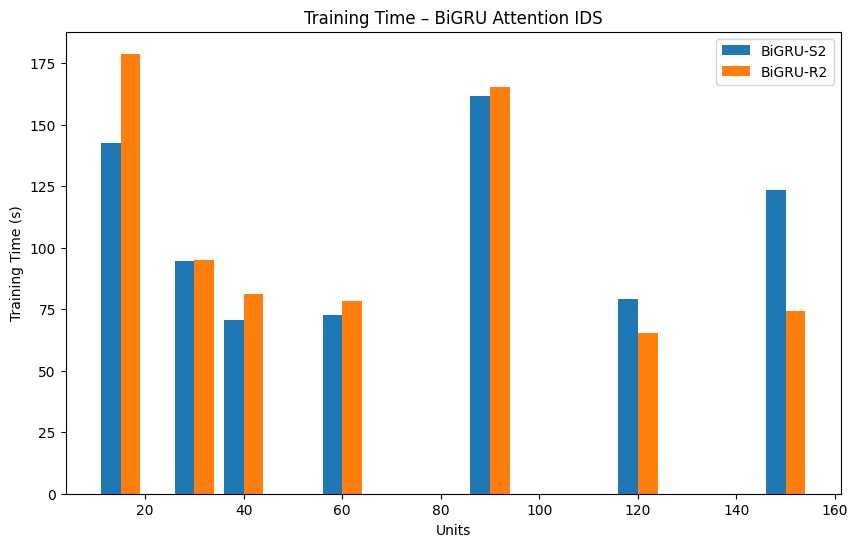

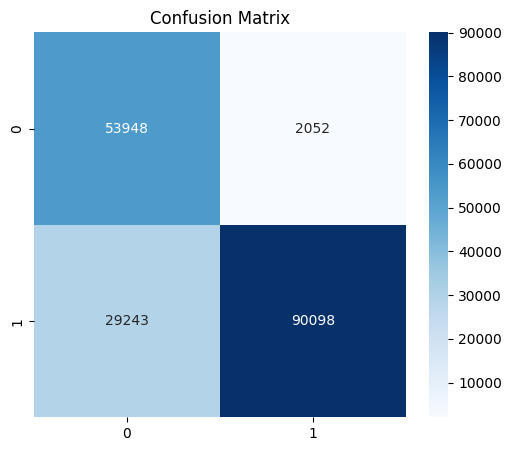

Computing SHAP...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_208
Received: inputs=['Tensor(shape=(100, 15, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_208
Received: inputs=['Tensor(shape=(50, 15, 1))']
  warnings.warn(msg)
/tmp/ipykernel_1117/1300764600.py:264: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


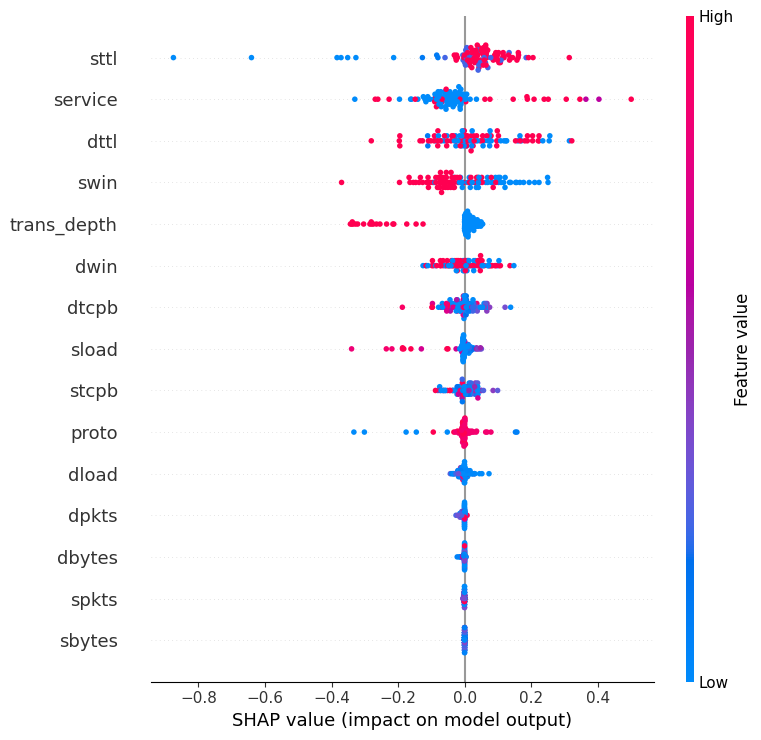

In [2]:
# =========================================================
# FINAL JOURNAL CODE
# Bi-Directional Attention GRU IDS – UNSW-NB15
# =========================================================

# =========================================================
# MOUNT GOOGLE DRIVE
# =========================================================
from google.colab import drive
drive.mount('/content/drive')

# =========================================================
# IMPORT LIBRARIES
# =========================================================
import pandas as pd
import numpy as np
import tensorflow as tf
import random
import time
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.utils import resample

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

# =========================================================
# RANDOM SEED
# =========================================================
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# =========================================================
# LOAD DATASET
# =========================================================
base_path = "/content/drive/MyDrive/UNSW_NB15/"

train_df = pd.read_csv(base_path + "UNSW_NB15_training-set.csv")
test_df  = pd.read_csv(base_path + "UNSW_NB15_testing-set.csv")

# =========================================================
# CLEANING
# =========================================================
drop_cols = ["srcip","dstip","sport","dsport","attack_cat"]
train_df = train_df.drop(columns=drop_cols, errors='ignore')
test_df  = test_df.drop(columns=drop_cols, errors='ignore')

# =========================================================
# ENCODING
# =========================================================
cat_cols = ["proto","service","state"]

for col in cat_cols:
    le = LabelEncoder()
    le.fit(pd.concat([train_df[col], test_df[col]]))
    train_df[col] = le.transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])

# =========================================================
# BALANCING
# =========================================================
df_normal = train_df[train_df.label == 0]
df_attack = train_df[train_df.label == 1]

df_attack = resample(df_attack,
                     replace=True,
                     n_samples=len(df_normal),
                     random_state=42)

train_df = pd.concat([df_normal, df_attack])

# =========================================================
# SPLIT
# =========================================================
train_df, val_df = train_test_split(
    train_df,
    test_size=0.25,
    stratify=train_df["label"],
    random_state=42
)

# =========================================================
# FEATURES
# =========================================================
top_features = [
    'sttl','dttl','sbytes','dbytes','sload','dload',
    'spkts','dpkts','swin','dwin',
    'stcpb','dtcpb',
    'trans_depth','service','proto'
]

X_train = train_df[top_features]
X_val   = val_df[top_features]
X_test  = test_df[top_features]

y_train = train_df["label"]
y_val   = val_df["label"]
y_test  = test_df["label"]

# =========================================================
# SCALING
# =========================================================
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

X_train = X_train.reshape(-1, len(top_features), 1)
X_val   = X_val.reshape(-1, len(top_features), 1)
X_test  = X_test.reshape(-1, len(top_features), 1)

# =========================================================
# 🔥 BUILD BIDIRECTIONAL ATTENTION GRU
# =========================================================
def build_bigru(nu, dense_type):

    inputs = Input(shape=(len(top_features),1))

    # 🔥 BiGRU Layer 1
    x = Bidirectional(GRU(nu, return_sequences=True))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    # 🔥 BiGRU Layer 2
    x = Bidirectional(GRU(nu, return_sequences=True))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    # =====================================================
    # ATTENTION
    # =====================================================
    score = Dense(64, activation="tanh")(x)
    score = Dense(32, activation="tanh")(score)
    score = Dense(1)(score)

    weights = tf.keras.layers.Softmax(axis=1)(score)
    attn = tf.keras.layers.Multiply()([x, weights])
    attn = tf.keras.layers.GlobalAveragePooling1D()(attn)

    # =====================================================
    # DENSE
    # =====================================================
    if dense_type == "R2":
        x = Dense(nu, activation="relu")(attn)
    else:
        x = Dense(nu, activation="sigmoid")(attn)

    x = Dropout(0.3)(x)

    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

# =========================================================
# TRAINING LOOP
# =========================================================
NU_list = [15,30,40,60,90,120,150]
results = []
last_model = None

for nu in NU_list:
    for dense in ["S2","R2"]:

        print("Training BiGRU NU =", nu, "Dense =", dense)

        model = build_bigru(nu, dense)

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )

        start = time.time()

        history = model.fit(
            X_train, y_train,
            epochs=50,
            batch_size=256,
            validation_data=(X_val, y_val),
            callbacks=[early_stop],
            verbose=0
        )

        Ts = time.time() - start
        VAC = max(history.history["val_accuracy"])

        probs = model.predict(X_test)
        preds = (probs > 0.5).astype(int)
        TAC = accuracy_score(y_test, preds)

        results.append([nu, dense, VAC, TAC, Ts])
        last_model = model

# =========================================================
# RESULTS
# =========================================================
results_df = pd.DataFrame(
    results,
    columns=["NU","Dense","VAC","TAC","Ts"]
)

print(results_df)

# =========================================================
# TRAINING TIME GRAPH
# =========================================================
import numpy as np

df_S2 = results_df[results_df["Dense"]=="S2"].sort_values("NU")
df_R2 = results_df[results_df["Dense"]=="R2"].sort_values("NU")

NU = df_S2["NU"]

plt.figure(figsize=(10,6))
plt.bar(np.array(NU)-2, df_S2["Ts"], width=4, label="BiGRU-S2")
plt.bar(np.array(NU)+2, df_R2["Ts"], width=4, label="BiGRU-R2")

plt.xlabel("Units")
plt.ylabel("Training Time (s)")
plt.title("Training Time – BiGRU Attention IDS")
plt.legend()
plt.show()

# =========================================================
# CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# =========================================================
# SHAP
# =========================================================
print("Computing SHAP...")

background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]

explainer = shap.GradientExplainer(last_model, background)
shap_values = explainer.shap_values(X_test[:100])

shap_values = np.array(shap_values).reshape(100, len(top_features))

plt.figure(figsize=(8,6))
shap.summary_plot(
    shap_values,
    X_test[:100].squeeze(axis=-1),
    feature_names=top_features,
    show=False
)
plt.show()